# 03_linear_svm

In [20]:
from pathlib import Path
import os
import re
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
warnings.filterwarnings("ignore")

In [21]:
# config

RANDOM_SEED = 42

TEXT_COL = "free_text"
LABEL_COL = "label_id"

LABEL_MAP = {
    0: "CLEAN",
    1: "OFFENSIVE",
    2: "HATE",
}

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
LOG_DIR = RESULTS_DIR / "logs"
PRED_DIR = RESULTS_DIR / "predictions"
MODEL_DIR = RESULTS_DIR / "models"

for d in [FIG_DIR, TABLE_DIR, LOG_DIR, PRED_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
DEV_PATH = DATA_DIR / "dev.csv"
TEST_PATH = DATA_DIR / "test.csv"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

In [22]:
# load data

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in [train_df, dev_df, test_df]:
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    df["label_name"] = df[LABEL_COL].map(LABEL_MAP)

print("train:", train_df.shape)
print("dev  :", dev_df.shape)
print("test :", test_df.shape)

train_df[[TEXT_COL, LABEL_COL, "label_name"]].head()

train: (24048, 3)
dev  : (2672, 3)
test : (6680, 3)


,free_text,label_id,label_name
0,Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]],0,CLEAN
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :))),2,HATE
2,Đậu Văn Cường giờ giống thằng sida hơn à,0,CLEAN
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.,2,HATE
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =)),0,CLEAN


## preprocessing


3 levels:
- `light`: almost no cleaning
- `medium`: lowercase + remove urls + normalize spaces
- `strong`: medium + reduce repeated punctuation/chars a bit

do not remove vietnamese diacritics.

In [23]:
# preprocess

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MULTISPACE_RE = re.compile(r"\s+")
REPEAT_PUNCT_RE = re.compile(r"([!?.,:;])\1{1,}")
REPEAT_CHAR_RE = re.compile(r"(.)\1{3,}")

def preprocess_light(text: str) -> str:
    text = str(text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

def preprocess_medium(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

def preprocess_strong(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = REPEAT_PUNCT_RE.sub(r"\1", text)
    text = REPEAT_CHAR_RE.sub(lambda m: m.group(1) * 2, text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

PREPROCESSORS = {
    "light": preprocess_light,
    "medium": preprocess_medium,
    "strong": preprocess_strong,
}

## feature configs

start with a few tf-idf settings that make sense for vietnamese social-media text:
- word unigram
- word uni+bigram
- char wb 3-5
- char wb 3-6

In [24]:
FEATURE_CONFIGS = {
    "word_unigram": {
        "analyzer": "word",
        "ngram_range": (1, 1),
        "min_df": 3,
        "max_df": 0.98,
        "sublinear_tf": True,
    },
    "word_uni_bigram": {
        "analyzer": "word",
        "ngram_range": (1, 2),
        "min_df": 3,
        "max_df": 0.98,
        "sublinear_tf": True,
    },
    "char_wb_3_5": {
        "analyzer": "char_wb",
        "ngram_range": (3, 5),
        "min_df": 3,
        "max_df": 1.0,
        "sublinear_tf": True,
    },
    "char_wb_3_6": {
        "analyzer": "char_wb",
        "ngram_range": (3, 6),
        "min_df": 3,
        "max_df": 1.0,
        "sublinear_tf": True,
    },
}

## linear svm configs

keep the grid small enough to finish quickly, but broad enough to be useful.

In [25]:
LINEAR_SVM_CONFIGS = [
    {"name": "lsvm_c0.1", "C": 0.1, "class_weight": None},
    {"name": "lsvm_c1", "C": 1.0, "class_weight": None},
    {"name": "lsvm_c5", "C": 5.0, "class_weight": None},
    {"name": "lsvm_c10", "C": 10.0, "class_weight": None},
    {"name": "lsvm_balanced_c0.1", "C": 0.1, "class_weight": "balanced"},
    {"name": "lsvm_balanced_c1", "C": 1.0, "class_weight": "balanced"},
    {"name": "lsvm_balanced_c5", "C": 5.0, "class_weight": "balanced"},
]

In [26]:
def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

def build_vectorizer(feature_cfg):
    kwargs = dict(
        analyzer=feature_cfg["analyzer"],
        ngram_range=feature_cfg["ngram_range"],
        min_df=feature_cfg["min_df"],
        max_df=feature_cfg["max_df"],
        sublinear_tf=feature_cfg["sublinear_tf"],
        lowercase=False,
    )
    return TfidfVectorizer(**kwargs)

def run_experiment(train_text, train_y, dev_text, dev_y, preprocessing_name, feature_name, feature_cfg, svm_cfg):
    vectorizer = build_vectorizer(feature_cfg)
    X_train = vectorizer.fit_transform(train_text)
    X_dev = vectorizer.transform(dev_text)

    model = LinearSVC(
        C=svm_cfg["C"],
        class_weight=svm_cfg["class_weight"],
        random_state=RANDOM_SEED,
    )

    model.fit(X_train, train_y)
    dev_pred = model.predict(X_dev)

    scores = evaluate_predictions(dev_y, dev_pred)
    row = {
        "preprocessing": preprocessing_name,
        "feature_name": feature_name,
        "analyzer": feature_cfg["analyzer"],
        "ngram_range": str(feature_cfg["ngram_range"]),
        "min_df": feature_cfg["min_df"],
        "max_df": feature_cfg["max_df"],
        "model_name": svm_cfg["name"],
        "C": svm_cfg["C"],
        "class_weight": str(svm_cfg["class_weight"]),
        "dev_accuracy": scores["accuracy"],
        "dev_macro_f1": scores["macro_f1"],
        "dev_weighted_f1": scores["weighted_f1"],
        "vocab_size": len(vectorizer.vocabulary_),
    }
    return row, vectorizer, model, dev_pred

## run experiments on the dev split

In [27]:
all_rows = []
artifacts = []

train_y = train_df[LABEL_COL].values
dev_y = dev_df[LABEL_COL].values

for prep_name, prep_fn in PREPROCESSORS.items():
    train_text = train_df[TEXT_COL].map(prep_fn)
    dev_text = dev_df[TEXT_COL].map(prep_fn)

    for feature_name, feature_cfg in FEATURE_CONFIGS.items():
        for svm_cfg in LINEAR_SVM_CONFIGS:
            row, vectorizer, model, dev_pred = run_experiment(
                train_text=train_text,
                train_y=train_y,
                dev_text=dev_text,
                dev_y=dev_y,
                preprocessing_name=prep_name,
                feature_name=feature_name,
                feature_cfg=feature_cfg,
                svm_cfg=svm_cfg,
            )
            all_rows.append(row)
            artifacts.append({
                "key": (prep_name, feature_name, svm_cfg["name"]),
                "vectorizer": vectorizer,
                "model": model,
                "dev_pred": dev_pred,
            })

results_df = pd.DataFrame(all_rows).sort_values(
    ["dev_macro_f1", "dev_weighted_f1", "dev_accuracy"],
    ascending=False,
).reset_index(drop=True)

results_df.head(15)

,preprocessing,feature_name,analyzer,ngram_range,min_df,max_df,model_name,C,class_weight,dev_accuracy,dev_macro_f1,dev_weighted_f1,vocab_size
0,strong,char_wb_3_5,char_wb,"(3, 5)",3,1.00,lsvm_balanced_c1,1.0,balanced,0.850674,0.635387,0.851645,29062
1,strong,char_wb_3_5,char_wb,"(3, 5)",3,1.00,lsvm_balanced_c0.1,0.1,balanced,0.858533,0.635247,0.852790,29062
2,medium,char_wb_3_5,char_wb,"(3, 5)",3,1.00,lsvm_balanced_c1,1.0,balanced,0.850674,0.632133,0.850506,29835
3,strong,char_wb_3_6,char_wb,"(3, 6)",3,1.00,lsvm_balanced_c0.1,0.1,balanced,0.856287,0.628505,0.850496,33184
4,strong,char_wb_3_6,char_wb,"(3, 6)",3,1.00,lsvm_balanced_c1,1.0,balanced,0.848428,0.628462,0.848628,33184
5,medium,char_wb_3_6,char_wb,"(3, 6)",3,1.00,lsvm_balanced_c0.1,0.1,balanced,0.855913,0.627740,0.849736,34321
6,medium,char_wb_3_5,char_wb,"(3, 5)",3,1.00,lsvm_balanced_c0.1,0.1,balanced,0.856287,0.627212,0.850000,29835
7,strong,char_wb_3_5,char_wb,"(3, 5)",3,1.00,lsvm_balanced_c5,5.0,balanced,0.844686,0.626231,0.846038,29062
8,medium,char_wb_3_6,char_wb,"(3, 6)",3,1.00,lsvm_balanced_c1,1.0,balanced,0.848428,0.625724,0.848089,34321
9,strong,word_uni_bigram,word,"(1, 2)",3,0.98,lsvm_balanced_c1,1.0,balanced,0.852545,0.625552,0.849304,19584


In [28]:
results_path = LOG_DIR / "linear_svm_experiments.csv"
results_df.to_csv(results_path, index=False)

best_row = results_df.iloc[0].to_dict()
best_key = (
    best_row["preprocessing"],
    best_row["feature_name"],
    best_row["model_name"],
)

best_artifact = None
for item in artifacts:
    if item["key"] == best_key:
        best_artifact = item
        break

best_vectorizer = best_artifact["vectorizer"]
best_model = best_artifact["model"]
best_dev_pred = best_artifact["dev_pred"]

best_row

{'preprocessing': 'strong',
 'feature_name': 'char_wb_3_5',
 'analyzer': 'char_wb',
 'ngram_range': '(3, 5)',
 'min_df': 3,
 'max_df': 1.0,
 'model_name': 'lsvm_balanced_c1',
 'C': 1.0,
 'class_weight': 'balanced',
 'dev_accuracy': 0.8506736526946108,
 'dev_macro_f1': 0.6353865090498952,
 'dev_weighted_f1': 0.8516452412046014,
 'vocab_size': 29062}

## quick summaries

In [29]:
summary_by_preprocessing = (
    results_df.groupby("preprocessing")[["dev_accuracy", "dev_macro_f1", "dev_weighted_f1"]]
    .max()
    .sort_values("dev_macro_f1", ascending=False)
)

summary_by_feature = (
    results_df.groupby("feature_name")[["dev_accuracy", "dev_macro_f1", "dev_weighted_f1"]]
    .max()
    .sort_values("dev_macro_f1", ascending=False)
)

summary_by_preprocessing.to_csv(TABLE_DIR / "linear_svm_preprocessing_max_scores.csv")
summary_by_feature.to_csv(TABLE_DIR / "linear_svm_feature_max_scores.csv")

display(summary_by_preprocessing)
display(summary_by_feature)

,dev_accuracy,dev_macro_f1,dev_weighted_f1
preprocessing,,,
strong,0.863772,0.635387,0.852790
medium,0.863024,0.632133,0.850506
light,0.863024,0.623598,0.848666


,dev_accuracy,dev_macro_f1,dev_weighted_f1
feature_name,,,
char_wb_3_5,0.863024,0.635387,0.852790
char_wb_3_6,0.861527,0.628505,0.850496
word_uni_bigram,0.863772,0.625552,0.850443
word_unigram,0.860030,0.618670,0.843393


## dev classification report for the best linear svm

In [30]:
best_report = classification_report(
    dev_y,
    best_dev_pred,
    target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP.keys())],
    output_dict=True,
    digits=4,
)

best_report_df = pd.DataFrame(best_report).transpose()
best_report_df.to_csv(TABLE_DIR / "best_linear_svm_dev_classification_report.csv")
best_report_df

,precision,recall,f1-score,support
CLEAN,0.934903,0.924658,0.929752,2190.000000
OFFENSIVE,0.446237,0.391509,0.417085,212.000000
HATE,0.515625,0.611111,0.559322,270.000000
accuracy,0.850674,0.850674,0.850674,0.850674
macro avg,0.632255,0.642426,0.635387,2672.000000
weighted avg,0.853764,0.850674,0.851645,2672.000000


In [31]:
cm = confusion_matrix(dev_y, best_dev_pred, labels=sorted(LABEL_MAP.keys()))
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{LABEL_MAP[i]}" for i in sorted(LABEL_MAP.keys())],
    columns=[f"pred_{LABEL_MAP[i]}" for i in sorted(LABEL_MAP.keys())],
)
cm_df.to_csv(TABLE_DIR / "best_linear_svm_dev_confusion_matrix.csv")
cm_df

,pred_CLEAN,pred_OFFENSIVE,pred_HATE
true_CLEAN,2025,70,95
true_OFFENSIVE,69,83,60
true_HATE,72,33,165


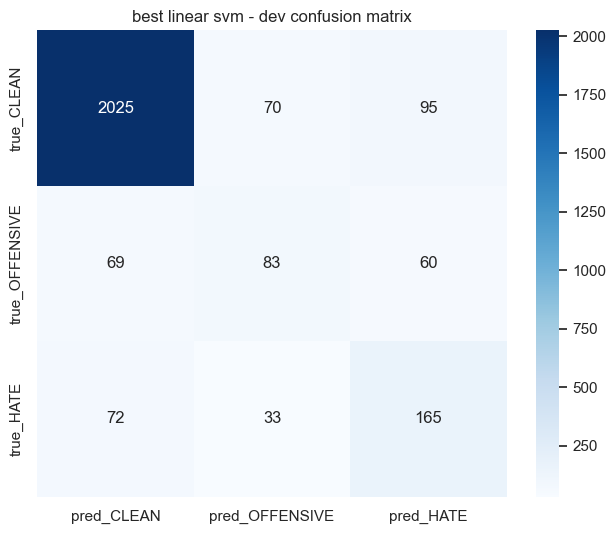

In [32]:
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
)
plt.title("best linear svm - dev confusion matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "best_linear_svm_dev_confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

## save best model and dev predictions

In [33]:
joblib.dump(best_vectorizer, MODEL_DIR / "best_linear_svm_vectorizer.joblib")
joblib.dump(best_model, MODEL_DIR / "best_linear_svm_model.joblib")

best_prep_name = best_row["preprocessing"]
best_prep_fn = PREPROCESSORS[best_prep_name]

dev_pred_df = dev_df.copy()
dev_pred_df["processed_text"] = dev_df[TEXT_COL].map(best_prep_fn)
dev_pred_df["pred_label_id"] = best_dev_pred
dev_pred_df["pred_label_name"] = dev_pred_df["pred_label_id"].map(LABEL_MAP)
dev_pred_df["is_correct"] = (dev_pred_df[LABEL_COL] == dev_pred_df["pred_label_id"]).astype(int)

dev_pred_df.to_csv(PRED_DIR / "best_linear_svm_dev_predictions.csv", index=False)

print("saved:")
print("-", results_path)
print("-", MODEL_DIR / "best_linear_svm_vectorizer.joblib")
print("-", MODEL_DIR / "best_linear_svm_model.joblib")
print("-", PRED_DIR / "best_linear_svm_dev_predictions.csv")

saved:
- c:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\Final_Project\results\logs\linear_svm_experiments.csv
- c:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\Final_Project\results\models\best_linear_svm_vectorizer.joblib
- c:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\Final_Project\results\models\best_linear_svm_model.joblib
- c:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\Final_Project\results\predictions\best_linear_svm_dev_predictions.csv


In [34]:
top_configs = results_df.head(8).copy()
top_configs.to_csv(TABLE_DIR / "top_linear_svm_configs.csv", index=False)
top_configs

,preprocessing,feature_name,analyzer,ngram_range,min_df,max_df,model_name,C,class_weight,dev_accuracy,dev_macro_f1,dev_weighted_f1,vocab_size
0,strong,char_wb_3_5,char_wb,"(3, 5)",3,1.0,lsvm_balanced_c1,1.0,balanced,0.850674,0.635387,0.851645,29062
1,strong,char_wb_3_5,char_wb,"(3, 5)",3,1.0,lsvm_balanced_c0.1,0.1,balanced,0.858533,0.635247,0.852790,29062
2,medium,char_wb_3_5,char_wb,"(3, 5)",3,1.0,lsvm_balanced_c1,1.0,balanced,0.850674,0.632133,0.850506,29835
3,strong,char_wb_3_6,char_wb,"(3, 6)",3,1.0,lsvm_balanced_c0.1,0.1,balanced,0.856287,0.628505,0.850496,33184
4,strong,char_wb_3_6,char_wb,"(3, 6)",3,1.0,lsvm_balanced_c1,1.0,balanced,0.848428,0.628462,0.848628,33184
5,medium,char_wb_3_6,char_wb,"(3, 6)",3,1.0,lsvm_balanced_c0.1,0.1,balanced,0.855913,0.627740,0.849736,34321
6,medium,char_wb_3_5,char_wb,"(3, 5)",3,1.0,lsvm_balanced_c0.1,0.1,balanced,0.856287,0.627212,0.850000,29835
7,strong,char_wb_3_5,char_wb,"(3, 5)",3,1.0,lsvm_balanced_c5,5.0,balanced,0.844686,0.626231,0.846038,29062
